In [ ]:
import cv2
import matplotlib.pyplot as DoanNhatKhoi

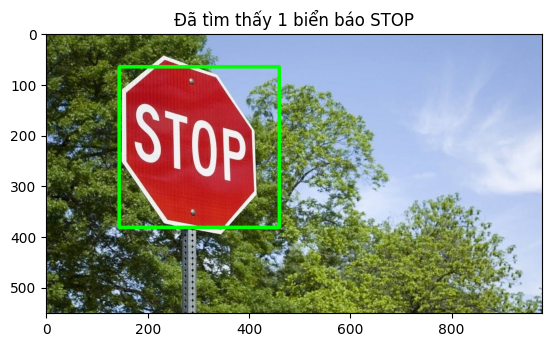

In [ ]:
img = cv2.imread('hinh1.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# nạp cascacade phát hiện biển báo dừng
stop_data = cv2.CascadeClassifier('stop_sign_classifier_2.xml')
found = stop_data.detectMultiScale(img_gray, minSize=(20, 20))  

amount_found = len(found)   # đếm số lượng biển báo dừng được phát hiện
if amount_found != 0:   # nếu phát hiện được ít nhất một biển báo dừng
    for (x, y, width, height) in found: # vẽ hình chữ nhật xung quanh biển báo dừng
        cv2.rectangle(img_rgb, (x, y), (x + width, y + height), (0, 255, 0), 5) # set hình chữ nhật màu xanh lá cây với độ dày 5 pixel

DoanNhatKhoi.imshow(img_rgb)   
DoanNhatKhoi.show()

In [ ]:
img2 = cv2.imread('hinh2.jpg')  # 
img_gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img_rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

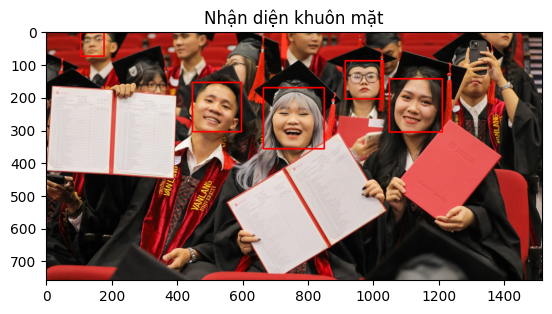

In [ ]:
face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')    # nạp cascacade phát hiện khuôn mặt
faces = face_cascade.detectMultiScale(img_gray2, scaleFactor=1.1, minNeighbors=5)       # set paramater cho hàm detectMultiScale để phát hiện khuôn mặt
                                                                                        # scaleFactor: tăng kích thước của ảnh để phát hiện các khuôn mặt nhỏ hơn
                                                                                        # minNeighbors: số lượng lân cận tối thiểu để xác nhận một khuôn mặt

for (x, y, w, h) in faces:  # vẽ hình chữ nhật xung quanh khuôn mặt được phát hiện
    cv2.rectangle(img_rgb2, (x, y), (x + w, y + h), (255, 0, 0), 3)     # set hình chữ nhật màu đỏ với độ dày 3 pixel
                                                                    
DoanNhatKhoi.title("Nhận diện khuôn mặt")
DoanNhatKhoi.imshow(img_rgb2)
DoanNhatKhoi.show()

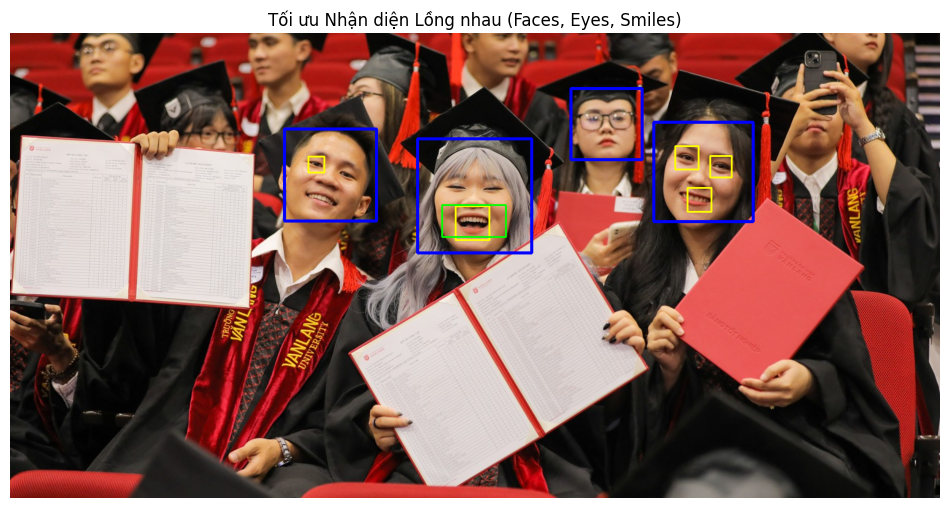

In [ ]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')

faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=6, minSize=(50, 50))  # minSize: kích thước tối thiểu của khuôn mặt được phát hiện

for (x, y, w, h) in faces:  # vẽ hình chữ nhật xung quanh khuôn mặt được phát hiện

    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 0, 255), 3)  # set hình chữ nhật màu xanh biển với độ dày 3 pixel

    roi_gray = img_gray[y:y+h, x:x+w]   # lấy vùng quan tâm (region of interest) là khuôn mặt được phát hiện
    roi_color = img_rgb[y:y+h, x:x+w]  

    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=12, minSize=(15, 15))   # set paramater cho hàm detectMultiScale để phát hiện mắt, ý nghĩa của các tham số giống như trên
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 255, 0), 2)    # set hình chữ nhật màu vàng với độ dày 2 pixel

    smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.7, minNeighbors=22, minSize=(25, 25))   # set paramater cho hàm detectMultiScale để phát hiện nụ cười, 
    #                                               vì chưa tối ưu đc tham số nên còn nhẫm lẫn giữa mắt với nụ cười, có thể do cascade chưa tới ưu cho mắt của người châu Á bé hơn so với bình thường
    for (sx, sy, sw, sh) in smiles:
        if sy > h // 2:
            cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 255, 0), 2)  # vẽ hình chữ nhật màu xanh lá cây với độ dày 2 pixel

DoanNhatKhoi.figure(figsize=(12, 8))
DoanNhatKhoi.imshow(img_rgb)
DoanNhatKhoi.axis('off')
DoanNhatKhoi.show()